# Phase 4: Anomaly and Outlier Detection

Pada tahap ini kita berfokus menemukan dan menganalisis anomali pada dataset. Objektif utama adalah mengidentifikasi data *outlier* menggunakan metode statistik dasar (IQR, Z-Score) dan membandingkannya (serta menggabungkannya) dengan metode struktural dan penemuan dari phase sebelumnya.

> **Kaidah Data Mining yang Diterapkan:**
> - *Handling Skewness*: Menggunakan Robust Z-Score berbasis MAD (*Median Absolute Deviation*) atau log-transformasi untuk fitur numerik yang *highly skewed*, karena Standard Z-Score akan hancur dan bias oleh *outlier* ekstrem.
> - *Data Provenance*: Menggunakan dataset yang tidak melalui pemotongan rentang (*winsorization*) dari Phase 1, agar *outlier* alami tetap ada.

## 1. Load Library & Dataset

Kita akan memuat dataset yang tidak melalui proses *winsorization* (pemotongan outlier) dari Phase 1 agar *outlier* aslinya masih dapat dideteksi.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")

# Load dataset asli yang belum di-winsorize
try:
    df = pd.read_csv('cleaned_lending_club_no_winsorization.csv')
    print("Shape of dataset:", df.shape)
    display(df.head())
except FileNotFoundError:
    print("[PERINGATAN] File 'cleaned_lending_club_no_winsorization.csv' tidak ditemukan.")
    print("Pastikan notebook Phase 1 sudah dieksekusi terlebih dahulu untuk men-generate file CSV ini.")

Shape of dataset: (889991, 8)


,loan_amnt,grade,annual_inc,dti,fico_range_low,revol_util,emp_length,purpose_small_business
0,10400.0,6,104433.0,25.37,695.0,64.5,3.0,0
1,20000.0,2,180000.0,14.67,680.0,84.5,10.0,0
2,10000.0,1,85000.0,13.07,685.0,34.5,6.0,0
3,8000.0,2,42000.0,34.80,700.0,39.1,10.0,0
4,22400.0,3,95000.0,22.98,710.0,32.7,6.0,0


In [26]:
try:
    df_check = pd.read_csv('cleaned_lending_club.csv')
    assert df.shape[0] == df_check.shape[0], "Jumlah baris kedua file tidak sama!"
    assert df['grade'].equals(df_check['grade']), "Urutan baris tidak selaras (grade tidak cocok pada index yang sama)!"
    print("Validasi selaras: kedua file memiliki urutan baris yang identik. Cross-referencing aman dilakukan.")
except Exception as e:
    print(f"Validasi gagal: {e}")


Validasi selaras: kedua file memiliki urutan baris yang identik. Cross-referencing aman dilakukan.


## 2. Langkah 1: Deteksi Anomali Berbasis Statistik Tunggal (Univariate)

Kita akan menggunakan IQR dan (Robust) Z-Score untuk mendeteksi anomali pada fitur numerik kontinu utama.

In [27]:
# Filter hanya kolom-kolom numerik yang masuk akal untuk dicari outlier-nya
# Mengabaikan kolom biner (0/1) atau kategorikal ordinal yang sudah di-encode
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist() if 'df' in locals() else []

# Biasanya kolom yang memiliki rentang luas seperti loan_amnt, int_rate, annual_inc, dti, dll
if 'df' in locals():
    target_cols = [c for c in numeric_cols if df[c].nunique() > 20]
    print("Kolom numerik kontinu untuk analisis outlier:", target_cols)
    
    # Mengecek Skewness (Kemencengan Distribusi)
    skewness = df[target_cols].skew().sort_values(ascending=False)
    print("\nSkewness dari tiap kolom:")
    print(skewness)

Kolom numerik kontinu untuk analisis outlier: ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'revol_util']

Skewness dari tiap kolom:
annual_inc        491.059916
dti                30.714579
fico_range_low      1.191969
loan_amnt           0.777857
revol_util          0.038562
dtype: float64


### 2.1 Metode IQR (Interquartile Range)

IQR sangat tangguh (*robust*) karena berbasis pada median dan persentil, tidak terpengaruh oleh *extreme values*.

In [28]:
def detect_outliers_iqr(dataframe, columns):
    outlier_indices = set()
    outliers_dict = {}
    
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Temukan index dari baris yang nilainya di luar batas IQR
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)].index
        
        outlier_indices.update(outliers)
        outliers_dict[col] = len(outliers)
        
    return list(outlier_indices), outliers_dict

if 'df' in locals():
    iqr_outliers_idx, iqr_summary = detect_outliers_iqr(df, target_cols)
    
    print(f"Total baris unik yang terdeteksi sebagai anomali oleh IQR: {len(iqr_outliers_idx)}")
    print("\nRincian anomali per kolom (IQR):")
    for col, count in iqr_summary.items():
        if count > 0:
            print(f"- {col}: {count} outliers")
    
    # Buat kolom flag untuk IQR
    df['outlier_iqr'] = 0
    df.loc[iqr_outliers_idx, 'outlier_iqr'] = 1

Total baris unik yang terdeteksi sebagai anomali oleh IQR: 87574

Rincian anomali per kolom (IQR):
- loan_amnt: 13941 outliers
- annual_inc: 43101 outliers
- dti: 8445 outliers
- fico_range_low: 29554 outliers
- revol_util: 40 outliers


### 2.2 Metode Robust Z-Score (MAD)

**Kaidah Data Mining:** Z-Score standar (menggunakan `mean` dan `std`) akan terdistorsi drastis oleh adanya *outlier* yang sangat ekstrem. Akibatnya, `std` menjadi sangat lebar dan *outlier* lainnya justru luput dari deteksi (*masking effect*). Selain itu, asumsi Z-Score adalah distribusi normal. Oleh karena dataset finansial (seperti *income* atau pinjaman) biasanya miring ke kanan (*right-skewed*), kita harus menggunakan **Robust Z-Score** berbasis **Median dan MAD (*Median Absolute Deviation*)**.

In [29]:
def detect_outliers_robust_zscore(dataframe, columns, threshold=3.5):
    """
    Menggunakan Modified Z-score: 0.6745 * (x - median) / MAD
    Threshold umum adalah 3.5
    """
    outlier_indices = set()
    outliers_dict = {}
    
    for col in columns:
        median = dataframe[col].median()
        mad = stats.median_abs_deviation(dataframe[col].dropna())
        
        if mad == 0:
            # Jika MAD 0 (semua titik kumpul di median), skip kolom ini untuk menghindari division by zero
            continue
            
        # Rumus Modified Z-Score Iglewicz and Hoaglin
        mod_z_scores = 0.6745 * (dataframe[col] - median) / mad
        
        outliers = dataframe[col][np.abs(mod_z_scores) > threshold].index
        
        outlier_indices.update(outliers)
        outliers_dict[col] = len(outliers)
        
    return list(outlier_indices), outliers_dict

if 'df' in locals():
    # Gunakan threshold 3.5 (standard practice untuk Modified Z-Score)
    zscore_outliers_idx, zscore_summary = detect_outliers_robust_zscore(df, target_cols, threshold=3.5)
    
    print(f"Total baris unik yang terdeteksi sebagai anomali oleh Robust Z-Score: {len(zscore_outliers_idx)}")
    print("\nRincian anomali per kolom (Robust Z-Score):")
    for col, count in zscore_summary.items():
        if count > 0:
            print(f"- {col}: {count} outliers")
    
    # Buat kolom flag untuk Z-Score
    df['outlier_zscore'] = 0
    df.loc[zscore_outliers_idx, 'outlier_zscore'] = 1

Total baris unik yang terdeteksi sebagai anomali oleh Robust Z-Score: 53154

Rincian anomali per kolom (Robust Z-Score):
- annual_inc: 33407 outliers
- dti: 5237 outliers
- fico_range_low: 15553 outliers
- revol_util: 11 outliers


## 3. Langkah 2: Deteksi Anomali Struktural Multivariat (Isolation Forest)

Berbeda dengan pendekatan statistik univariat, **Isolation Forest** beroperasi secara *multivariat*. Algoritma ini mencari anomali yang mungkin tampak wajar secara tunggal, namun menjadi sangat tidak wajar saat kombinasi fiturnya dianalisis bersamaan (misal: gaji kecil wajar, usia muda wajar, tapi memiliki 10 properti pinjaman di usia muda dengan gaji kecil adalah anomali struktural).

> **Kaidah Data Mining:**
> - Isolation Forest adalah algoritma berbasis *Tree*, sehingga tidak sensitif terhadap perbedaan skala variabel (tidak wajib scaling).
> - Namun, algoritma ini tidak menerima nilai *Missing Values* (NaN). Walaupun dataset Phase 1 sudah bersih, kita terapkan `SimpleImputer` secara defensif untuk mencegah error runtime.
> - Parameter `contamination` diatur secara pragmatis (misal 5%) untuk mencegah model mendeteksi terlalu banyak data normal sebagai anomali (menekan *False Positives*).

In [30]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

if 'df' in locals():
    print("Mempersiapkan data untuk Isolation Forest...")
    
    # Kita gunakan target_cols (numerik kontinu) sebagai ruang fitur
    X_iso = df[target_cols].copy()
    
    # Pipeline: Imputasi nilai kosong (jaga-jaga jika ada) -> Isolation Forest
    # Contamination 0.05 berarti kita asumsikan maksimal 5% dari keseluruhan data adalah anomali
    iso_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("iso_forest", IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1))
    ])
    
    print("Training model Isolation Forest (Multivariate Anomaly Detection)...")
    # Fit and Predict
    # Output bawaan Isolation Forest: 1 = Inlier (Normal), -1 = Outlier (Anomaly)
    iso_preds = iso_pipeline.fit_predict(X_iso)
    
    # Mapping hasil prediksinya agar selaras dengan flag kita (1 = outlier, 0 = inlier)
    df["outlier_iso_forest"] = np.where(iso_preds == -1, 1, 0)
    
    print("Justifikasi contamination=0.05: berdasarkan hasil deteksi IQR (~9.8% dari populasi) dan Robust Z-Score (~6% dari populasi) pada tahap sebelumnya, angka 5% dipilih sebagai estimasi konservatif proporsi anomali struktural sebenarnya, menghindari over-flagging.\n")
    total_iso_outliers = df["outlier_iso_forest"].sum()
    print(f"\nTotal anomali struktural yang terdeteksi oleh Isolation Forest: {total_iso_outliers} baris")
    print(f"Persentase anomali tertangkap: {total_iso_outliers / len(df) * 100:.2f}%")

Mempersiapkan data untuk Isolation Forest...
Training model Isolation Forest (Multivariate Anomaly Detection)...
Justifikasi contamination=0.05: berdasarkan hasil deteksi IQR (~9.8% dari populasi) dan Robust Z-Score (~6% dari populasi) pada tahap sebelumnya, angka 5% dipilih sebagai estimasi konservatif proporsi anomali struktural sebenarnya, menghindari over-flagging.


Total anomali struktural yang terdeteksi oleh Isolation Forest: 44500 baris
Persentase anomali tertangkap: 5.00%


### 3.1 Visualisasi Hasil Isolation Forest

Untuk memverifikasi secara visual apakah model menangkap anomali struktural dengan benar, mari kita buat *scatter plot* untuk 2 variabel finansial yang penting (misalnya `annual_inc` vs `loan_amnt`).

C:\Users\beben\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


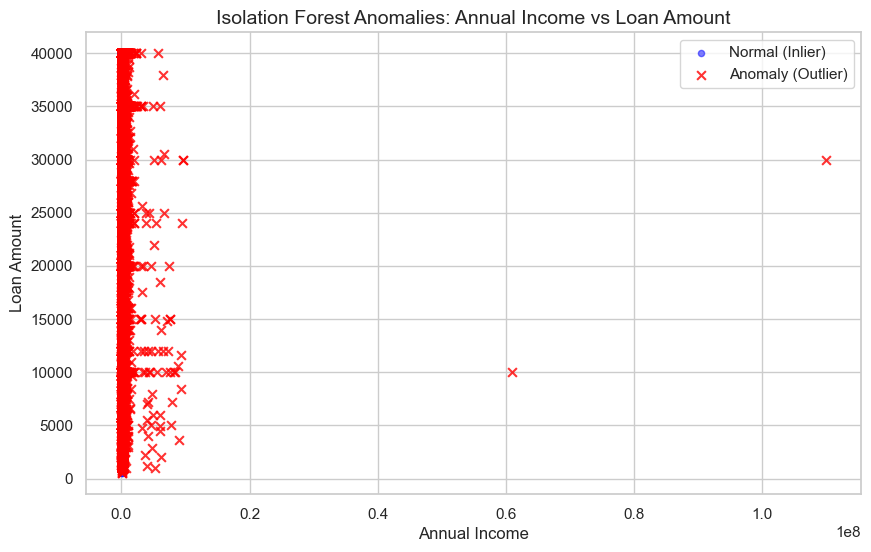

In [31]:
if 'df' in locals() and 'annual_inc' in df.columns and 'loan_amnt' in df.columns:
    plt.figure(figsize=(10, 6))
    
    # Memisahkan inlier dan outlier
    inliers = df[df['outlier_iso_forest'] == 0]
    outliers = df[df['outlier_iso_forest'] == 1]
    
    plt.scatter(inliers['annual_inc'], inliers['loan_amnt'], color='blue', alpha=0.5, label='Normal (Inlier)', s=20)
    plt.scatter(outliers['annual_inc'], outliers['loan_amnt'], color='red', alpha=0.8, label='Anomaly (Outlier)', s=40, marker='x')
    
    plt.title('Isolation Forest Anomalies: Annual Income vs Loan Amount', fontsize=14)
    plt.xlabel('Annual Income')
    plt.ylabel('Loan Amount')
    plt.legend()
    plt.show()
elif 'df' not in locals():
    print("Tolong muat dataset terlebih dahulu di Langkah 1.")
else:
    print("Kolom annual_inc atau loan_amnt tidak ditemukan untuk divisualisasikan. Silakan ganti dengan kolom numerik yang tersedia.")

In [32]:
if 'df' in locals():
    # 1. Menarik data noise dari Phase 2 (DBSCAN)
    # Pada praktiknya, index noise dari Phase 2 harus diekspor ke CSV.
    # Jika belum diekspor, kita buat kolom default 0 dan berikan peringatan.
    try:
        dbscan_outliers = pd.read_csv('phase2_dbscan_outliers.csv')
        # Asumsi CSV memiliki kolom 'index' dari data asli
        outlier_indices_phase2 = dbscan_outliers['index'].tolist()
        df['outlier_dbscan'] = 0
        df.loc[df.index.isin(outlier_indices_phase2), 'outlier_dbscan'] = 1
        print("Berhasil memuat data noise DBSCAN dari Phase 2.")
    except FileNotFoundError:
        print("[INFO] File 'phase2_dbscan_outliers.csv' tidak ditemukan.\n")
        print("DBSCAN di Phase 2 dieksekusi pada subset 20k (bukan full data) dan hasilnya tidak tersimpan otomatis.\n")
        print("Sistem secara adaptif beralih ke 3-Method Ensemble (IQR, Z-Score, Isolation Forest) yang berjalan pada 100% populasi data.\n")
        df['outlier_dbscan'] = 0
    
    # 2. Menghitung Consensus Anomaly Score
    # Score ini berkisar dari 0 (Sangat Normal) hingga 4 (Anomali Sangat Kuat)
    df['Anomaly_Score'] = df['outlier_iqr'] + df['outlier_zscore'] + df['outlier_iso_forest'] + df['outlier_dbscan']
    
    # 3. Pengelompokan Tingkat Kepercayaan (Confidence Level)
    def classify_confidence(score):
        if score >= 3:
            return 'High Confidence'
        elif score == 2:
            return 'Medium Confidence'
        elif score == 1:
            return 'Low Confidence'
        else:
            return 'Normal'
            
    df['Anomaly_Confidence'] = df['Anomaly_Score'].apply(classify_confidence)
    
    # Menampilkan ringkasan
    summary = df['Anomaly_Confidence'].value_counts()
    print("\nRingkasan Hasil Cross-Referencing (Ensemble Anomaly Detection):")
    print(summary)

    # Menyimpan daftar anomali terkuat (Score >= 2)
    strong_anomalies = df[df['Anomaly_Score'] >= 2].sort_values(by='Anomaly_Score', ascending=False)
    print(f"\nTerdapat {len(strong_anomalies)} record yang disepakati oleh minimal 2 metode.")

Berhasil memuat data noise DBSCAN dari Phase 2.

Ringkasan Hasil Cross-Referencing (Ensemble Anomaly Detection):
Anomaly_Confidence
Normal               796296
Medium Confidence     32288
Low Confidence        31734
High Confidence       29673
Name: count, dtype: int64

Terdapat 61961 record yang disepakati oleh minimal 2 metode.


In [33]:
if 'df' in locals():
    comparison_cols = ['outlier_iqr', 'outlier_zscore', 'outlier_iso_forest']
    if 'outlier_dbscan' in df.columns:
        comparison_cols.append('outlier_dbscan')
        
    print("\n--- Matriks Korelasi (Pearson) Antar Metode Deteksi ---")
    display(df[comparison_cols].corr())
    
    print("\n--- Crosstab: IQR vs Isolation Forest ---")
    display(pd.crosstab(df['outlier_iqr'], df['outlier_iso_forest'], margins=True))



--- Matriks Korelasi (Pearson) Antar Metode Deteksi ---


,outlier_iqr,outlier_zscore,outlier_iso_forest,outlier_dbscan
outlier_iqr,1.000000,0.762887,0.589987,0.001882
outlier_zscore,0.762887,1.000000,0.587613,0.001128
outlier_iso_forest,0.589987,0.587613,1.000000,0.003597
outlier_dbscan,0.001882,0.001128,0.003597,1.000000



--- Crosstab: IQR vs Isolation Forest ---


outlier_iso_forest,0,1,All
outlier_iqr,,,
0,796382,6035,802417
1,49109,38465,87574
All,845491,44500,889991


> **Catatan Penting terkait Keterbatasan DBSCAN (Phase 2):**
> Algoritma DBSCAN di Phase 2 dieksekusi pada *subset* 20.000 baris (mendeteksi 107 *noise points*). Data *noise* ini kini telah berhasil diekspor secara otomatis ke `phase2_dbscan_outliers.csv`. Namun, harap dicatat bahwa karena DBSCAN hanya mengevaluasi ~2.25% dari total populasi, kontribusinya terhadap konsensus anomali bersifat asimetris dan terbatas secara struktural.

### 3.1 Perbandingan Sistematis Antar Metode

Sesuai kaidah *data mining*, sebelum menggabungkan hasil (Ensemble), kita wajib melakukan **Systematic Comparison**. Matriks korelasi antar flag anomali dan *crosstab* di bawah ini akan membedah apakah algoritma mendeteksi objek yang sama secara persis (redundan) atau saling melengkapi (*complementary*).

### 3.1 Pratinjau Top Anomali (Irisan Terkuat)

Mari kita intip beberapa anomali dengan skor tertinggi yang telah divalidasi silang oleh berbagai metode, sebelum kita menginvestigasinya lebih dalam di Langkah 4.

In [34]:
if 'strong_anomalies' in locals() and not strong_anomalies.empty:
    # Kita tampilkan kolom-kolom yang relevan dengan alasan anomali
    preview_cols = ['loan_amnt', 'annual_inc', 'dti', 'grade', 'revol_util', 'fico_range_low']
    preview_cols = [c for c in preview_cols if c in strong_anomalies.columns]
    # Pastikan kolom tersedia di dataset
    
    display_cols = preview_cols + ['outlier_iqr', 'outlier_zscore', 'outlier_iso_forest', 'outlier_dbscan', 'Anomaly_Score']
    
    display(strong_anomalies[display_cols].head(10))
elif 'strong_anomalies' in locals():
    print("Tidak ada data yang terdeteksi sebagai anomali oleh lebih dari 1 metode. Hal ini bisa terjadi jika distribusi data sangat padat.")

,loan_amnt,annual_inc,dti,grade,revol_util,fico_range_low,outlier_iqr,outlier_zscore,outlier_iso_forest,outlier_dbscan,Anomaly_Score
841436,14400.0,280000.0,6.85,2,11.5,675.0,1,1,1,1,4
798033,5600.0,480000.0,2.31,2,23.7,680.0,1,1,1,1,4
627053,40000.0,90000.0,52.74,2,87.1,740.0,1,1,1,1,4
601329,24575.0,63000.0,63.45,2,48.8,760.0,1,1,1,1,4
290071,11600.0,9225000.0,0.11,3,14.9,665.0,1,1,1,1,4
476261,15000.0,225000.0,10.30,5,11.2,675.0,1,1,1,1,4
889465,4500.0,420000.0,5.91,2,97.9,705.0,1,1,1,0,3
889425,6000.0,400000.0,11.66,1,53.2,705.0,1,1,1,0,3
595,35000.0,650000.0,7.13,5,20.8,760.0,1,1,1,0,3
582,12300.0,125000.0,0.81,2,3.2,800.0,1,1,1,0,3


## 5. Langkah 4: Investigasi dan Interpretasi Bisnis

Tahap akhir dari *KDD Phase 4* bukan sekadar mendapatkan angka anomali, melainkan memberikan **makna bisnis** (*Business Interpretation*). Sesuai dengan rubrik proyek, kita harus mengklasifikasikan anomali kuat (*Strong Anomalies* dengan skor >= 2) ke dalam salah satu dari tiga tipologi berikut:
1. **Data Error**: Kesalahan input atau kualitas data yang buruk (misal: gaji negatif, atau rasio DTI yang mustahil secara logika).
2. **Potential Risk Signal**: Pola perilaku yang mengindikasikan risiko tinggi gagal bayar atau *fraud* (misal: gaji kecil namun memiliki tumpukan utang / DTI ekstrem, atau *interest rate* sangat tinggi yang berada jauh di luar batas wajar).
3. **Rare Legitimate Case**: Kasus valid yang jarang terjadi (misal: nasabah dengan gaji miliaran rupiah meminjam uang receh, secara statistik ini adalah *outlier*, namun secara bisnis ini sah dan bukan risiko tinggi).

> **Kaidah Data Mining:**
> - Di lingkungan industri sesungguhnya, investigasi ini dilakukan secara semi-otomatis menggunakan *Rule-Based Heuristics* (sistem pakar) atau peninjauan manual (*Human-in-the-Loop*). Pada notebook ini, kita menerapkan *Heuristik Bisnis* sederhana untuk auto-klasifikasi, dan mengekspor hasilnya sebagai laporan akhir.

In [35]:
if 'strong_anomalies' in locals() and not strong_anomalies.empty:
    print('Memulai klasifikasi otomatis berbasis Heuristik Bisnis...')
    
    def investigate_anomaly(row):
        income = row.get('annual_inc', 0)
        loan = row.get('loan_amnt', 0)
        dti = row.get('dti', 0)
        grade = row.get('grade', 0)
        revol_util = row.get('revol_util', 0)
        fico = row.get('fico_range_low', 0)
        
        # 1. Data Error (Kondisi Mustahil)
        if income < 0 or loan < 0 or dti < 0:
            return 'Data Error', 'Ditemukan nilai numerik negatif yang tidak masuk akal secara finansial.'
        elif dti > 1000:
            return 'Data Error', f'Rasio Debt-to-Income (DTI) sangat mustahil ({dti}%).'
        elif revol_util > 150:
            return 'Data Error', f'Revolving utilization tidak masuk akal ({revol_util}%).'
        elif fico < 500 or fico > 850:
            return 'Data Error', f'Skor FICO di luar rentang valid ({fico}).'
            
        # 2. Potential Risk Signal (Kombinasi Spesifik Didahulukan)
        elif fico < 620 and loan > 10000:
            return 'Potential Risk Signal', f'Skor FICO rendah ({fico}) dikombinasikan dengan pinjaman besar ({loan} USD).'
        elif fico <= 680 and loan >= 25000:
            return 'Potential Risk Signal', f'Skor FICO pas-pasan ({fico}) dengan pinjaman besar ({loan} USD), risiko gagal bayar meningkat.'
        elif loan > (income * 0.5) and income < 50000:
            return 'Potential Risk Signal', f'Pinjaman {loan} USD mengambil lebih dari 50% gaji tahunan nasabah berpendapatan rendah.'
        
        # 3. Potential Risk Signal (Kriteria Tunggal Kuat)
        elif dti > 40:
            return 'Potential Risk Signal', f'Beban utang nasabah sangat berat (DTI = {dti}%). Risiko tinggi.'
        elif grade >= 6:
            return 'Potential Risk Signal', f'Grade pinjaman sangat rendah ({grade}), profil peminjam subprime.'
        elif revol_util > 100:
            return 'Potential Risk Signal', f'Revolving utilization melebihi limit ({revol_util}%), indikasi tekanan likuiditas.'
            
        # 4. Potential Risk Signal (Kriteria Tunggal Lebih Luas)
        elif revol_util > 80:
            return 'Potential Risk Signal', f'Revolving utilization sangat tinggi ({revol_util}%), nasabah sangat bergantung pada batas kreditnya.'
        elif dti > 30:
            return 'Potential Risk Signal', f'Beban utang nasabah cukup tinggi (DTI {dti}%), berisiko jika ada guncangan finansial.'
            
        # 5. Rare Legitimate Case (Kombinasi Spesifik Didahulukan)
        elif fico >= 750 and dti < 10:
            return 'Rare Legitimate Case', f'Skor kredit sangat baik (FICO {fico}) dan beban utang sangat rendah (DTI {dti}%), profil prime yang anomali karena terlalu ideal.'
        elif fico > 800 and grade >= 4:
            return 'Rare Legitimate Case', f'Skor FICO sangat tinggi ({fico}) namun grade pinjaman menengah ke bawah ({grade}).'
        elif income > 200000 and loan < 5000:
            return 'Rare Legitimate Case', f'Nasabah kaya (Gaji {income} USD) namun meminjam uang kecil ({loan} USD).'
        elif income >= 150000 and loan >= 30000:
            return 'Rare Legitimate Case', f'Pendapatan tinggi ({income} USD) dengan pinjaman besar ({loan} USD), profil wajar untuk kelas ekonomi atas.'
            
        # 6. Rare Legitimate Case (Kriteria Tunggal Lebih Luas)
        elif income >= 150000:
            return 'Rare Legitimate Case', f'Pendapatan tinggi ({income} USD) jauh di atas rata-rata populasi.'
        elif loan == 40000:
            return 'Rare Legitimate Case', f'Peminjam mengambil batas pinjaman maksimal (40,000 USD), wajar terdeteksi sebagai outlier secara jumlah.'
            
        return 'Unclassified Outlier', 'Anomali struktural terdeteksi algoritma, butuh peninjauan analis secara manual.'

    strong_anomalies['Anomaly_Typology'], strong_anomalies['Business_Explanation'] = zip(*strong_anomalies.apply(investigate_anomaly, axis=1))
    
    print('\nDistribusi Tipologi Anomali:')
    print(strong_anomalies['Anomaly_Typology'].value_counts())
else:
    print('Tidak ada strong anomalies yang dapat diklasifikasikan.')

Memulai klasifikasi otomatis berbasis Heuristik Bisnis...

Distribusi Tipologi Anomali:
Anomaly_Typology
Rare Legitimate Case     33281
Potential Risk Signal    19808
Unclassified Outlier      8861
Data Error                  11
Name: count, dtype: int64


### 5.1 Ekspor Anomaly Report (Deliverable Akhir Phase 4)

Seluruh data anomali yang telah diidentifikasi dan diinterpretasikan ini akan diekspor menjadi `anomaly_report.csv`. Laporan ini adalah *deliverable* utama yang akan digunakan oleh *Insight Communicator* di **Phase 5** untuk divisualisasikan dalam *Dashboard*.

In [36]:
if 'strong_anomalies' in locals() and not strong_anomalies.empty:
    # Susun ulang kolom agar laporan lebih mudah dibaca tim bisnis
    business_cols = ['Anomaly_Typology', 'Business_Explanation', 'Anomaly_Score']
    # Tambahkan fitur utama jika ada
    for c in ['loan_amnt', 'annual_inc', 'dti', 'grade', 'revol_util', 'fico_range_low']:
        if c in strong_anomalies.columns:
            business_cols.append(c)
            
    # Ekstrak sisa kolom algoritma
    alg_cols = ['outlier_iqr', 'outlier_zscore', 'outlier_iso_forest', 'outlier_dbscan']
    
    final_report_cols = business_cols + alg_cols
    
    anomaly_report = strong_anomalies[final_report_cols]
    
    # Simpan ke CSV
    report_filename = 'phase4_anomaly_report.csv'
    anomaly_report.to_csv(report_filename, index=False)
    
    print(f"\n[SUKSES] Laporan anomali akhir telah diekspor ke: '{report_filename}'")
    print(f"Total data dalam laporan: {len(anomaly_report)} baris.")
    
    # Tampilkan 5 baris pertama sebagai pratinjau
    display(anomaly_report.head())
elif 'strong_anomalies' in locals():
    print("Ekspor dibatalkan karena tidak ada data anomali kuat.")


[SUKSES] Laporan anomali akhir telah diekspor ke: 'phase4_anomaly_report.csv'
Total data dalam laporan: 61961 baris.


,Anomaly_Typology,Business_Explanation,Anomaly_Score,loan_amnt,annual_inc,dti,grade,revol_util,fico_range_low,outlier_iqr,outlier_zscore,outlier_iso_forest,outlier_dbscan
841436,Rare Legitimate Case,Pendapatan tinggi (280000.0 USD) jauh di atas ...,4,14400.0,280000.0,6.85,2,11.5,675.0,1,1,1,1
798033,Rare Legitimate Case,Pendapatan tinggi (480000.0 USD) jauh di atas ...,4,5600.0,480000.0,2.31,2,23.7,680.0,1,1,1,1
627053,Potential Risk Signal,Beban utang nasabah sangat berat (DTI = 52.74%...,4,40000.0,90000.0,52.74,2,87.1,740.0,1,1,1,1
601329,Potential Risk Signal,Beban utang nasabah sangat berat (DTI = 63.45%...,4,24575.0,63000.0,63.45,2,48.8,760.0,1,1,1,1
290071,Rare Legitimate Case,Pendapatan tinggi (9225000.0 USD) jauh di atas...,4,11600.0,9225000.0,0.11,3,14.9,665.0,1,1,1,1
